In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ====================================================
# TAHAP 1: BACA DATA & PRA-PEMROSESAN (DATA CLEANING)
# ====================================================
print("=== PROSES PEMBERSIHAN DATA (DATA CLEANING) ===")
df_raw = pd.read_excel('3TIA_11_PenggunaSosmed.xlsx')
print(f"1. Membaca data awal: Ditemukan {df_raw.shape[0]} baris dan {df_raw.shape[1]} kolom.")

# Proses Data Cleaning
df = df_raw.dropna().drop_duplicates()
df = df[df['Daily_Usage_Time (minutes)'] > 0].copy()
print(f"2. Setelah dibersihkan (hapus NaN & Duplikat): Tersisa {df.shape[0]} baris.")

# Membuat variabel turunan baru
df['Total_Interaksi'] = (df['Posts_Per_Day'] + df['Likes_Received_Per_Day']
                         + df['Comments_Received_Per_Day'] + df['Messages_Sent_Per_Day'])
print(f"3. Berhasil membuat variabel turunan baru: 'Total_Interaksi'.")

WAKTU = 'Daily_Usage_Time (minutes)'
INTER = 'Total_Interaksi'
kolom = [WAKTU, INTER]

# Pengaturan Palet Warna (Tema Hijau Elegan)
HIJAU_TUA = '#14532D'
BG = '#eaf6ed'
C_WAKTU = '#10b981'
C_INTER = '#3b82f6'
C_MEAN = '#dc2626'
C_MEDIAN = '#f59e0b'

def gaya_axes(ax):
    """Fungsi untuk mengatur desain grid dan warna grafik"""
    ax.set_facecolor(BG)
    ax.grid(axis='y', linestyle='--', alpha=0.5, color=HIJAU_TUA)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color(HIJAU_TUA)
    ax.spines['left'].set_color(HIJAU_TUA)
    ax.tick_params(colors=HIJAU_TUA)
    ax.title.set_color(HIJAU_TUA)
    ax.title.set_fontweight('bold')
    ax.xaxis.label.set_color(HIJAU_TUA)
    ax.yaxis.label.set_color(HIJAU_TUA)
    ax.xaxis.label.set_fontweight('bold')
    ax.yaxis.label.set_fontweight('bold')

=== PROSES PEMBERSIHAN DATA (DATA CLEANING) ===
1. Membaca data awal: Ditemukan 1000 baris dan 10 kolom.
2. Setelah dibersihkan (hapus NaN & Duplikat): Tersisa 1000 baris.
3. Berhasil membuat variabel turunan baru: 'Total_Interaksi'.


In [ ]:
# ====================================================
# TAHAP 2: TABEL FREKUENSI PLATFORM MEDIA SOSIAL
# ====================================================
print("\n=== TABEL FREKUENSI PLATFORM MEDIA SOSIAL ===")
freq_platform = df['Platform'].value_counts().reset_index()
freq_platform.columns = ['Platform', 'Frekuensi']
freq_platform['Persentase (%)'] = freq_platform['Frekuensi'] / len(df) * 100

styled_freq = (freq_platform.style.format({'Persentase (%)': "{:.1f}"})
    .set_properties(**{'background-color': BG, 'color': HIJAU_TUA, 'border': '1px solid white'})
    .background_gradient(subset=['Frekuensi'], cmap='YlGn')
    .set_table_styles([{'selector': 'th', 'props': [('background-color', HIJAU_TUA),
                                                    ('color', 'white'), ('font-weight', 'bold')]}]))
display(styled_freq)


=== TABEL FREKUENSI PLATFORM MEDIA SOSIAL ===


,Platform,Frekuensi,Persentase (%)
0,Instagram,250,25.0
1,Twitter,200,20.0
2,Facebook,190,19.0
3,LinkedIn,120,12.0
4,Whatsapp,80,8.0
5,Telegram,80,8.0
6,Snapchat,80,8.0


/tmp/ipykernel_1371/1907570124.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Platform', order=urutan, palette='YlGn_r', ax=axes[1, 2])


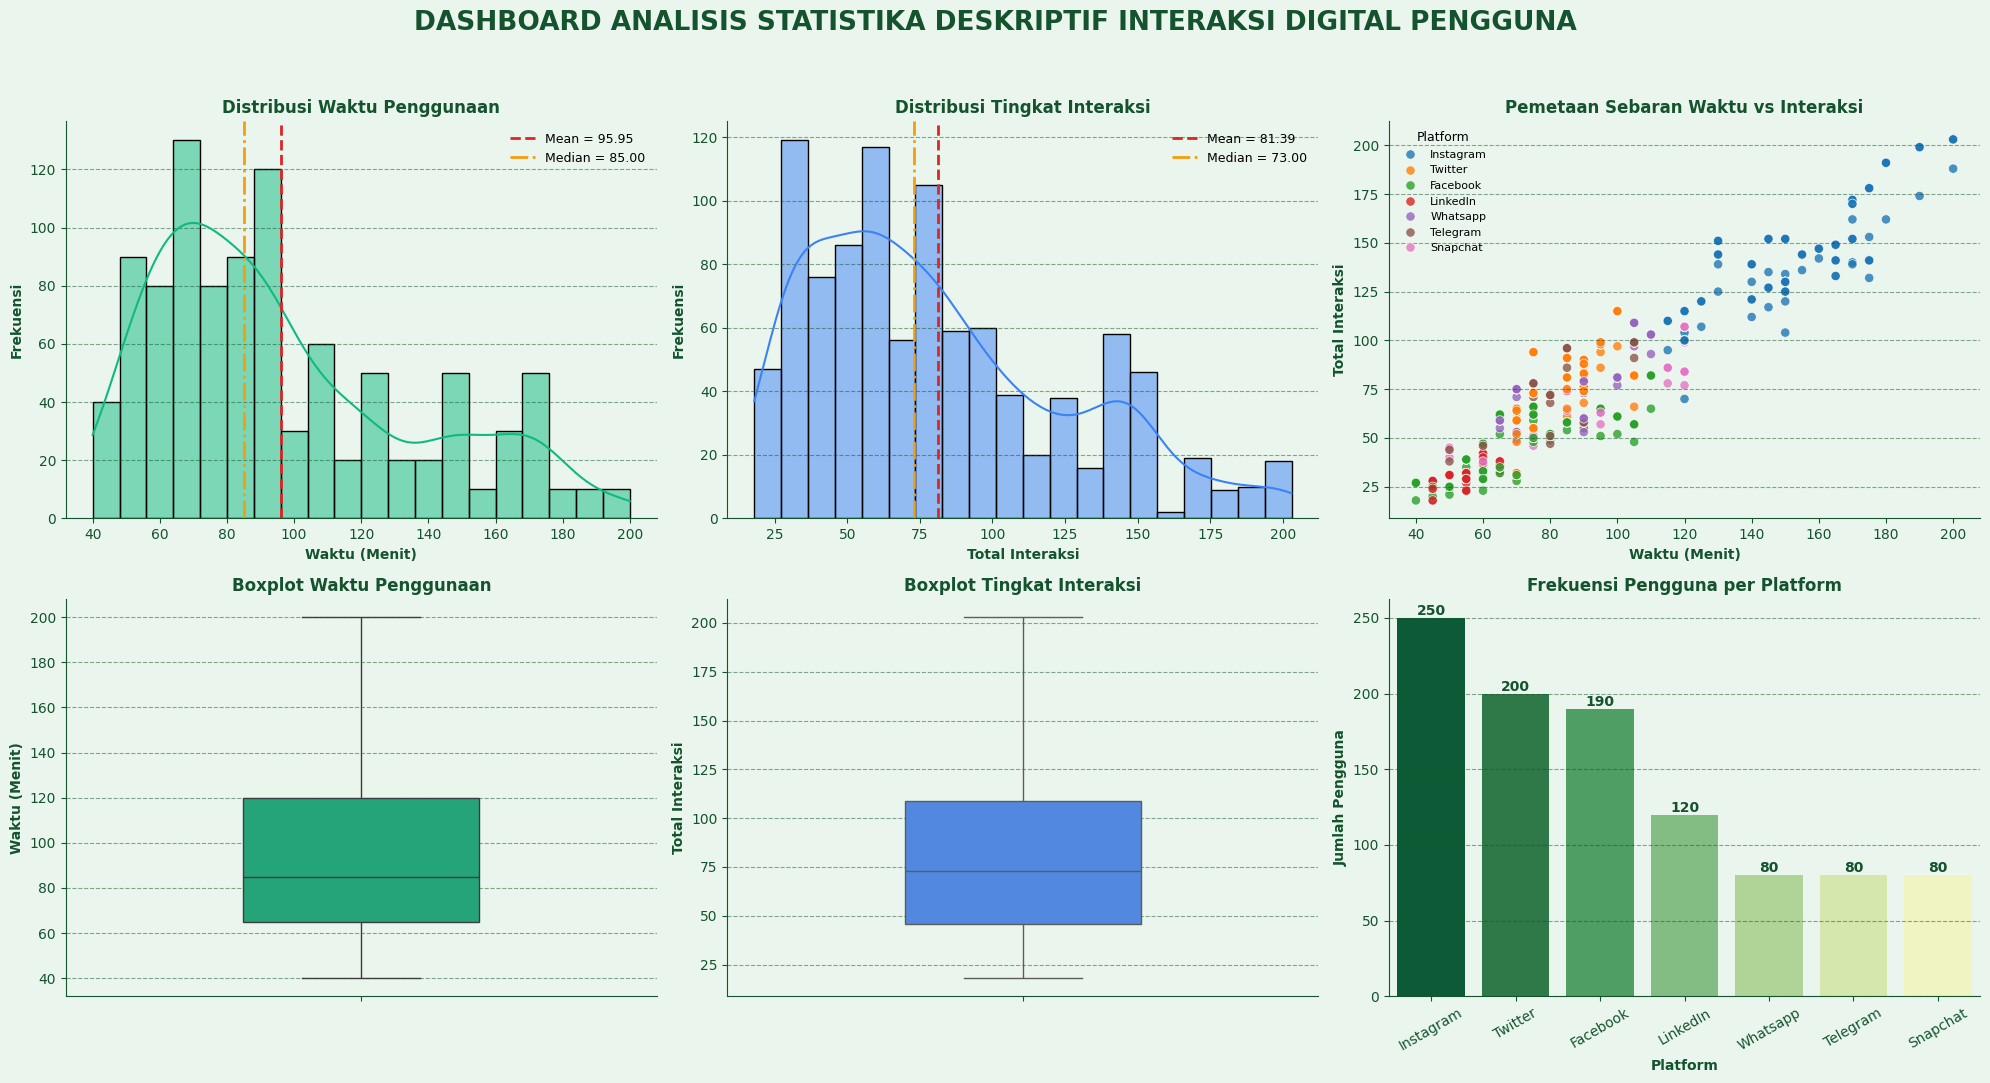

In [ ]:
# ====================================================
# TAHAP 3: DASHBOARD VISUALISASI UTAMA (Murni Deskriptif)
# ====================================================
def hist_mean_median(ax, kolom_data, warna, judul, xlabel):
    sns.histplot(df[kolom_data], kde=True, color=warna, bins=20, ax=ax)
    ax.axvline(df[kolom_data].mean(), color=C_MEAN, linestyle='--', linewidth=2,
               label=f'Mean = {df[kolom_data].mean():.2f}')
    ax.axvline(df[kolom_data].median(), color=C_MEDIAN, linestyle='-.', linewidth=2,
               label=f'Median = {df[kolom_data].median():.2f}')
    ax.set_title(judul)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=9, frameon=False)
    gaya_axes(ax)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.patch.set_facecolor(BG)
fig.suptitle('DASHBOARD ANALISIS STATISTIKA DESKRIPTIF INTERAKSI DIGITAL PENGGUNA',
             fontsize=19, fontweight='bold', color=HIJAU_TUA, y=0.98)

# 1 & 2. Histogram Waktu dan Interaksi
hist_mean_median(axes[0, 0], WAKTU, C_WAKTU, 'Distribusi Waktu Penggunaan', 'Waktu (Menit)')
hist_mean_median(axes[0, 1], INTER, C_INTER, 'Distribusi Tingkat Interaksi', 'Total Interaksi')

# 3. Scatter Plot (Tanpa garis regresi/korelasi Pearson)
sns.scatterplot(x=WAKTU, y=INTER, hue='Platform', data=df, ax=axes[0, 2], s=45, alpha=0.8, palette='tab10')
axes[0, 2].set_title('Pemetaan Sebaran Waktu vs Interaksi')
axes[0, 2].set_xlabel('Waktu (Menit)')
axes[0, 2].set_ylabel('Total Interaksi')
axes[0, 2].legend(title='Platform', fontsize=8, title_fontsize=9, frameon=False)
gaya_axes(axes[0, 2])

# 4 & 5. Boxplot
sns.boxplot(y=df[WAKTU], color=C_WAKTU, ax=axes[1, 0], width=0.4)
axes[1, 0].set_title('Boxplot Waktu Penggunaan')
axes[1, 0].set_ylabel('Waktu (Menit)')
gaya_axes(axes[1, 0])

sns.boxplot(y=df[INTER], color=C_INTER, ax=axes[1, 1], width=0.4)
axes[1, 1].set_title('Boxplot Tingkat Interaksi')
axes[1, 1].set_ylabel('Total Interaksi')
gaya_axes(axes[1, 1])

# 6. Bar Chart Platform
urutan = df['Platform'].value_counts().index
sns.countplot(data=df, x='Platform', order=urutan, palette='YlGn_r', ax=axes[1, 2])
for p in axes[1, 2].patches:
    axes[1, 2].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=10, color=HIJAU_TUA, fontweight='bold')
axes[1, 2].set_title('Frekuensi Pengguna per Platform')
axes[1, 2].set_xlabel('Platform')
axes[1, 2].set_ylabel('Jumlah Pengguna')
axes[1, 2].tick_params(axis='x', rotation=30)
gaya_axes(axes[1, 2])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('dashboard_utama.png', dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [ ]:
# ====================================================
# TAHAP 4: TABEL STATISTIKA DESKRIPTIF LENGKAP
# ====================================================
print("\n=== TABEL STATISTIKA DESKRIPTIF LENGKAP ===")
ringkas = pd.DataFrame({
    'Count': df[kolom].count(),
    'Sum': df[kolom].sum(),
    'Mean': df[kolom].mean(),
    'Median': df[kolom].median(),
    'Modus': df[kolom].mode().iloc[0],
    'Std Deviasi': df[kolom].std(),
    'Varians': df[kolom].var(),
    'Standard Error': df[kolom].sem(),
    'Minimum': df[kolom].min(),
    'Q1 (25%)': df[kolom].quantile(0.25),
    'Q3 (75%)': df[kolom].quantile(0.75),
    'Maksimum': df[kolom].max(),
    'Range': df[kolom].max() - df[kolom].min(),
    'IQR': df[kolom].quantile(0.75) - df[kolom].quantile(0.25),
    'Skewness': df[kolom].skew(),
    'Kurtosis': df[kolom].kurtosis(),
    'CV (%)': df[kolom].std() / df[kolom].mean() * 100
}).T.round(3)

styled_stats = (ringkas.style.format("{:,.3f}")
    .set_properties(**{'background-color': BG, 'color': HIJAU_TUA, 'border': '1px solid white'})
    .background_gradient(cmap='YlGn', axis=None)
    .set_table_styles([{'selector': 'th', 'props': [('background-color', HIJAU_TUA),
                                                    ('color', 'white'), ('font-weight', 'bold')]}]))
display(styled_stats)


=== TABEL STATISTIKA DESKRIPTIF LENGKAP ===


,Daily_Usage_Time (minutes),Total_Interaksi
Count,"1,000.000","1,000.000"
Sum,"95,950.000","81,390.000"
Mean,95.950,81.390
Median,85.000,73.000
Modus,60.000,29.000
Std Deviasi,38.850,44.476
Varians,"1,509.357","1,978.098"
Standard Error,1.229,1.406
Minimum,40.000,18.000
Q1 (25%),65.000,46.000


In [ ]:
# ====================================================
# TAHAP 5: DETEKSI PENCILAN (OUTLIER) MENGGUNAKAN METODE IQR
# ====================================================
print("\n=== PEMERIKSAAN PENCILAN (ATURAN IQR) ===")
for k in kolom:
    q1, q3 = df[k].quantile(0.25), df[k].quantile(0.75)
    iqr = q3 - q1
    bawah, atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[k] < bawah) | (df[k] > atas)).sum()
    print(f"Variabel {k}:")
    print(f" -> Batas Bawah = {bawah:.2f}")
    print(f" -> Batas Atas  = {atas:.2f}")
    print(f" -> Kesimpulan  = Ditemukan {n_out} Outlier\n")


=== PEMERIKSAAN PENCILAN (ATURAN IQR) ===
Variabel Daily_Usage_Time (minutes):
 -> Batas Bawah = -17.50
 -> Batas Atas  = 202.50
 -> Kesimpulan  = Ditemukan 0 Outlier

Variabel Total_Interaksi:
 -> Batas Bawah = -48.50
 -> Batas Atas  = 203.50
 -> Kesimpulan  = Ditemukan 0 Outlier



In [ ]:
# ====================================================
# TAHAP 6: TABEL DISTRIBUSI FREKUENSI STURGES
# ====================================================
print("\n=== DISTRIBUSI FREKUENSI BERKELOMPOK (ATURAN STURGES) ===")
n = len(df)
k = int(np.round(1 + 3.322 * np.log10(n)))
range_waktu = df[WAKTU].max() - df[WAKTU].min()
c_waktu = int(np.ceil(range_waktu / k))

print(f"Berdasarkan Aturan Sturges:")
print(f"- Jumlah Data (n) = {n}")
print(f"- Banyak Kelas (k) = {k} kelas interval")
print(f"- Panjang Kelas (c) = {c_waktu} menit\n")

batas_waktu = [df[WAKTU].min() + i * c_waktu for i in range(k + 1)]
kelas_waktu = pd.cut(df[WAKTU], bins=batas_waktu, right=False, include_lowest=True)
tabel_sturges_waktu = kelas_waktu.value_counts().sort_index().reset_index()
tabel_sturges_waktu.columns = ['Kelas Interval Waktu (Menit)', 'Frekuensi']

styled_sturges = (tabel_sturges_waktu.style
    .set_properties(**{'background-color': BG, 'color': HIJAU_TUA, 'border': '1px solid white'})
    .set_table_styles([{'selector': 'th', 'props': [('background-color', HIJAU_TUA), ('color', 'white'), ('font-weight', 'bold')]}]))
display(styled_sturges)


=== DISTRIBUSI FREKUENSI BERKELOMPOK (ATURAN STURGES) ===
Berdasarkan Aturan Sturges:
- Jumlah Data (n) = 1000
- Banyak Kelas (k) = 11 kelas interval
- Panjang Kelas (c) = 15 menit



,Kelas Interval Waktu (Menit),Frekuensi
0,"[40, 55)",80
1,"[55, 70)",180
2,"[70, 85)",190
3,"[85, 100)",180
4,"[100, 115)",90
5,"[115, 130)",70
6,"[130, 145)",40
7,"[145, 160)",60
8,"[160, 175)",60
9,"[175, 190)",30
